In [2]:
# load the dataset
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, ConfusionMatrixDisplay

dataset = load_iris()
X, y = dataset['data'], dataset['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state=42)

In [3]:
def validate_model(y_pred_test, y_test, clf, X, y):
    test_accuracy = accuracy_score(y_test, y_pred_test)
    classification_rep = classification_report(y_test, y_pred_test, output_dict=True)
    # cross validation score 
    cv_score = cross_val_score(clf, X, y, cv=5)
    
    print(f"Accuracy of the model (testing) is: {test_accuracy * 100:.2f}%")
    print(f"Classification Report:\n{classification_report(y_test, y_pred_test)}")
    print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_test)}")
    
    print(f"Cross Validation Scores: {cv_score * 100}")
    print(f"Mean Cross Validation Score: {cv_score.mean() * 100:.2f}%")

In [4]:

# using grid_serach for determining the best param
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

parameters = {
    "criterion": ["gini", "entropy"],
    "max_depth": [2, 3, 4, 5, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    parameters,
    cv=5
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 10}


In [5]:
clf = DecisionTreeClassifier( criterion= grid.best_params_['criterion'], max_depth=grid.best_params_['max_depth'], 
                             min_samples_split=grid.best_params_['min_samples_split'], 
                             min_samples_leaf=grid.best_params_['min_samples_leaf'], random_state=42)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [6]:
validate_model(y_pred, y_test, clf, X, y)

Accuracy of the model (testing) is: 100.00%
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
Cross Validation Scores: [ 96.66666667  96.66666667  93.33333333  96.66666667 100.        ]
Mean Cross Validation Score: 96.67%


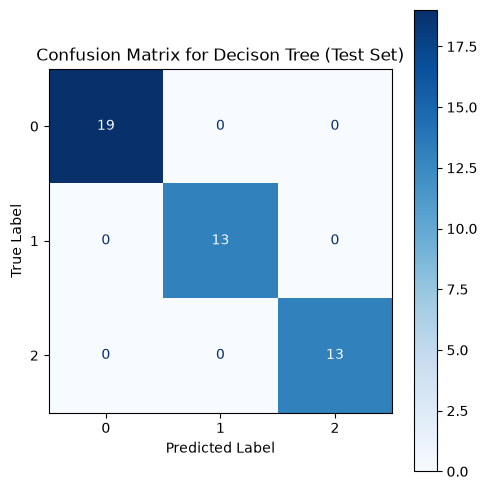

In [10]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix for Decison Tree (Test Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Test Result - Report 
The trained model was evaluated on the test dataset and achieved the following performance:

1. Accuracy: 100.00%
2. Precision (Weighted): 100.00%
3. Recall (Weighted): 100.00%
4. F1-Score (Weighted): 100.00%

The confusion matrix indicates that all test samples were classified correctly, with no false positives or false negatives for any of the three Iris classes.

Cross-validation accuracies:

- Fold 1: 96.67%
- Fold 2: 96.67%
- Fold 3: 93.33%
- Fold 4: 96.67%
- Fold 5: 100.00%

Mean Cross-Validation Accuracy: 96.67%. 

This extends the truth that  the model will be accurate when tested on real world inputs